https://www.kaggle.com/datasets/abdallahwagih/company-employees

Dataset "Company Employees" của tác giả Abdallah Wagih (thường hay dùng cho các bài toán phân tích nhân sự - HR Analytics và Machine Learning) là một tập dữ liệu tập trung vào việc dự đoán khả năng nghỉ việc/rời bỏ công ty (Employee Churn / Attrition Prediction) dựa trên thông tin nhân khẩu học và lịch sử công việc của nhân viên

1. Các cột chính (Features) trong DatasetTập dữ liệu thường bao gồm các trường thông tin cơ bản sau:   Education: Trình độ học vấn của nhân viên (ví dụ: Bachelors - Cử nhân, Masters - Thạc sĩ, PHD hoặc các bằng cấp khác).   JoiningYear: Năm nhân viên gia nhập công ty. Cột này giúp tính thâm niên làm việc (Length of Service).   City: Thành phố hoặc chi nhánh văn phòng nơi nhân viên làm việc (ví dụ: Bangalore, Pune, New Delhi,...).   PaymentTier: Bậc lương của nhân viên (thường chia thành các mức từ 1 đến 3, trong đó Tier 1 có thể là mức lương cao nhất hoặc cấu trúc phân khúc công ty).   Age: Tuổi của nhân viên.   Gender: Giới tính (Male / Female).   EverBenched: Biến boolean (Yes/No) thể hiện nhân viên đã từng có khoảng thời gian nào bị "benched" (chờ dự án, chưa được phân công công việc chính thức) hay chưa.   ExperienceInCurrentDomain: Số năm kinh nghiệm làm việc trong lĩnh vực chuyên môn hiện tại của họ.   LeaveOrNot (Target Column): Cột nhãn (label) cần dự đoán. Thường mang giá trị 0 hoặc 1:   0: Nhân viên tiếp tục ở lại công ty (Retention).1: Nhân viên đã hoặc sẽ rời công ty trong một khoảng thời gian xác định (Attrition / Churn).

2. Mục đích và Bài toán phổ biến (Use Cases)Bài toán Phân loại (Classification / Predictive Modeling): Xây dựng các mô hình Machine Learning (như Logistic Regression, Random Forest, XGBoost, LightGBM) để dự đoán xem một nhân viên có nguy cơ nghỉ việc hay không (LeaveOrNot) dựa trên các đặc trưng về thâm niên, mức lương, việc có bị rảnh rỗi (benched) hay không.Phân tích Khám phá Dữ liệu (EDA):   Khảo sát xem yếu tố nào ảnh hưởng lớn nhất đến việc nhân viên rời bỏ công ty (Ví dụ: Bậc lương thấp? Hay việc từng bị benched quá lâu?).Xem xét sự phân bố giới tính, trình độ học vấn theo từng chi nhánh/thành phố.

In [1]:
import pandas as pd

In [5]:
data = pd.read_excel("Employees.xlsx")

In [6]:
data.head()

,No,First Name,Last Name,Gender,Start Date,Years,Department,Country,Center,Monthly Salary,Annual Salary,Job Rate,Sick Leaves,Unpaid Leaves,Overtime Hours
0,1,Ghadir,Hmshw,Male,2018-04-04,2,Quality Control,Egypt,West,1560,18720,3.0,1,0,183
1,2,Omar,Hishan,Male,2020-05-21,0,Quality Control,Saudi Arabia,West,3247,38964,1.0,0,5,198
2,3,Ailya,Sharaf,Female,2017-09-28,3,Major Mfg Projects,Saudi Arabia,West,2506,30072,2.0,0,3,192
3,4,Lwiy,Qbany,Male,2018-08-14,2,Manufacturing,United Arab Emirates,Main,1828,21936,3.0,0,0,7
4,5,Ahmad,Bikri,Male,2020-03-11,0,Manufacturing,Egypt,Main,970,11640,5.0,0,5,121


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   No              689 non-null    int64         
 1   First Name      689 non-null    object        
 2   Last Name       689 non-null    object        
 3   Gender          689 non-null    object        
 4   Start Date      689 non-null    datetime64[ns]
 5   Years           689 non-null    int64         
 6   Department      689 non-null    object        
 7   Country         689 non-null    object        
 8   Center          689 non-null    object        
 9   Monthly Salary  689 non-null    int64         
 10  Annual Salary   689 non-null    int64         
 11  Job Rate        689 non-null    float64       
 12  Sick Leaves     689 non-null    int64         
 13  Unpaid Leaves   689 non-null    int64         
 14  Overtime Hours  689 non-null    int64         
dtypes: dat

In [8]:
data.shape

(689, 15)

In [10]:
data.isna().sum()

No                0
First Name        0
Last Name         0
Gender            0
Start Date        0
Years             0
Department        0
Country           0
Center            0
Monthly Salary    0
Annual Salary     0
Job Rate          0
Sick Leaves       0
Unpaid Leaves     0
Overtime Hours    0
dtype: int64

In [ ]:
#data.dropna(inplace=true) for the if exist data na

In [11]:
data.duplicated().sum()

np.int64(0)

In [ ]:
#data.drop_duplicates(inplace=True) for dropping duplicates

In [12]:
data["Gender"].value_counts()

Gender
Male      449
Female    240
Name: count, dtype: int64

In [13]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Pie Char of Gender Column')

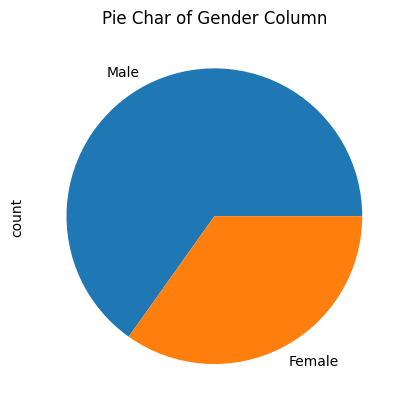

In [16]:
data["Gender"].value_counts().sort_values(ascending=False).plot(kind="pie")
plt.title("Pie Char of Gender Column")

Text(0, 0.5, 'Count')

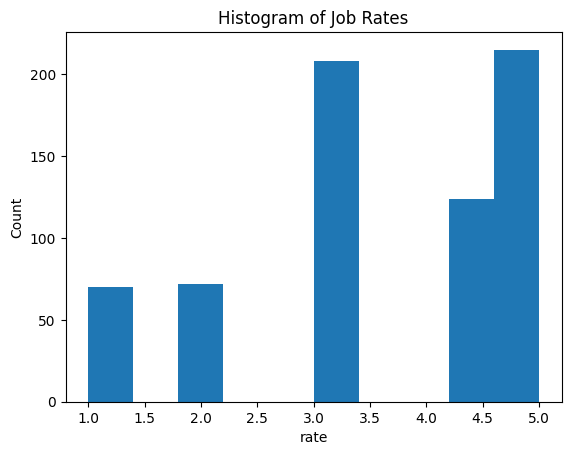

In [17]:
plt.hist(data["Job Rate"])
plt.title("Histogram of Job Rates")
plt.xlabel("rate")
plt.ylabel("Count")

In [18]:
data["Job Rate"].describe()

count    689.000000
mean       3.586357
std        1.350125
min        1.000000
25%        3.000000
50%        3.000000
75%        5.000000
max        5.000000
Name: Job Rate, dtype: float64

Text(0, 0.5, 'Average Salary')

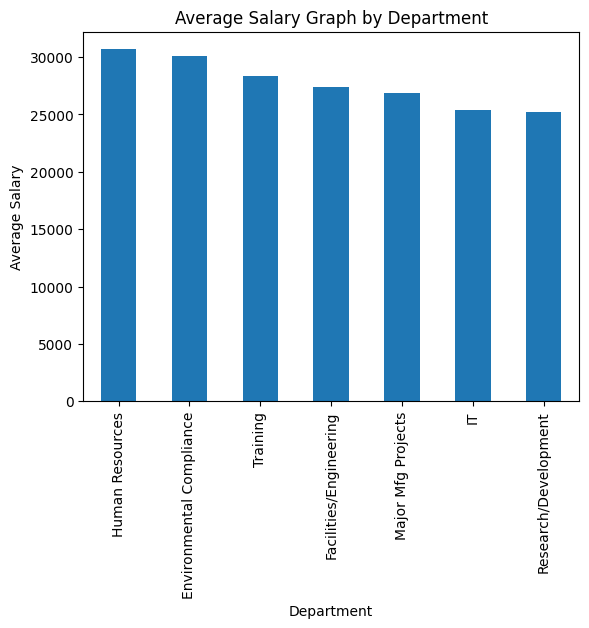

In [25]:
data.groupby("Department")["Annual Salary"].mean().sort_values(ascending=False).head(7).plot(kind='bar')
plt.title("Average Salary Graph by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

In [26]:
data.groupby("Center")["Monthly Salary"].mean().sort_values(ascending=False)

Center
East     2274.021277
West     2068.672269
North    2064.811594
Main     2054.776892
South    1981.153846
Name: Monthly Salary, dtype: float64

In [27]:
data["Country"].unique()

array(['Egypt', 'Saudi Arabia', 'United Arab Emirates', 'Syria',
       'Lebanon'], dtype=object)

Text(0, 0.5, 'job rate average')

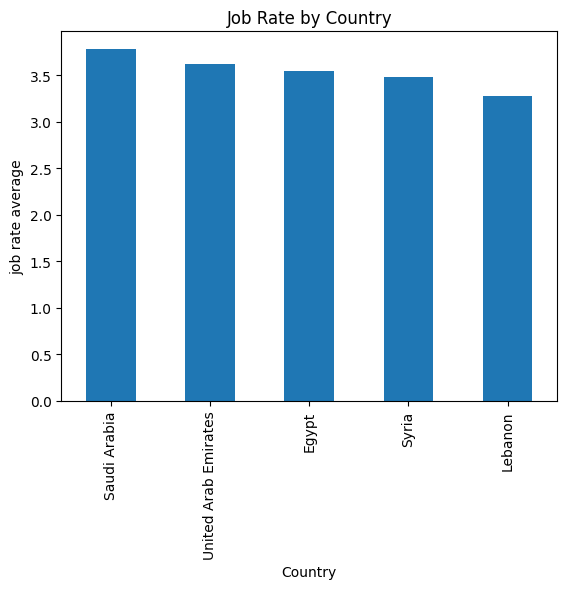

In [29]:
data.groupby("Country")["Job Rate"].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Job Rate by Country")
plt.xlabel("Country")
plt.ylabel("job rate average")

Text(0, 0.5, 'Frequency')

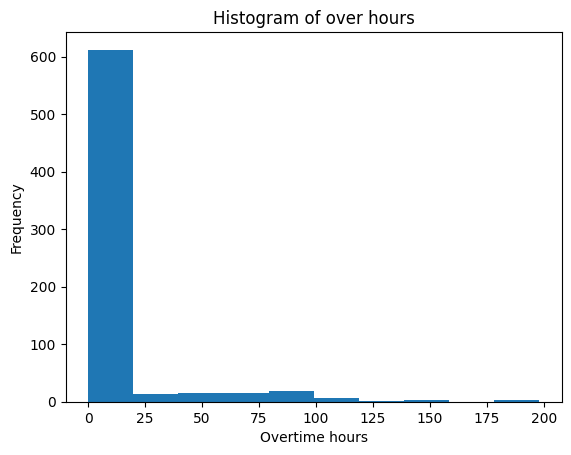

In [32]:
plt.hist(data["Overtime Hours"])
plt.title("Histogram of over hours")
plt.xlabel("Overtime hours")
plt.ylabel("Frequency")

In [34]:
data["Overtime Hours"].describe()

count    689.000000
mean      13.702467
std       25.692049
min        0.000000
25%        3.000000
50%        7.000000
75%       10.000000
max      198.000000
Name: Overtime Hours, dtype: float64

In [35]:
data["Annual Salary"].describe()

count      689.000000
mean     24818.420900
std       9159.470878
min       8436.000000
25%      17232.000000
50%      24924.000000
75%      32184.000000
max      41400.000000
Name: Annual Salary, dtype: float64

In [36]:
data.columns

Index(['No', 'First Name', 'Last Name', 'Gender', 'Start Date', 'Years',
       'Department', 'Country', 'Center', 'Monthly Salary', 'Annual Salary',
       'Job Rate', 'Sick Leaves', 'Unpaid Leaves', 'Overtime Hours'],
      dtype='object')

In [37]:
X = data[["Years", "Job Rate"]]
y = data["Annual Salary"]

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [40]:
len(X_train)

551

In [41]:
len(X_test)

138

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
lr = LinearRegression()

In [44]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
pre_lr = lr.predict(X_test)

In [46]:
from sklearn.metrics import mean_absolute_error

In [47]:
mean_absolute_error(pre_lr, y_test)

7664.829653648437

In [48]:
import joblib
joblib.dump(lr, "linearmodel.pkl")

['linearmodel.pkl']